# Pseudospectral Numerical Methods

Pseudospectral (collocation) methods represent a function by its values at $N+1$ carefully chosen
**collocation points**, build a global polynomial or trigonometric interpolant through those values,
and approximate operations on the function (differentiation, integration) by exact operations on
the interpolant. For smooth (analytic) functions the error decays *faster than any algebraic rate*
in $N$ — so-called **spectral accuracy** — which is why a pseudospectral solver with $N=32$ can
match a finite-difference solver with thousands of points.

This notebook covers:

1. **Fourier pseudospectral** differentiation (periodic problems).
2. **Chebyshev pseudospectral** differentiation (non-periodic problems on $[-1,1]$).
3. **Clenshaw–Curtis quadrature** for definite integrals.
4. **Boundary-value problems** via the Chebyshev differentiation matrix.
5. A **time-dependent PDE** (heat equation) integrated exactly in Fourier space.
6. An **eigenvalue problem** (quantum harmonic oscillator).

Standard references: L. N. Trefethen, *Spectral Methods in MATLAB* (SIAM, 2000); J. P. Boyd,
*Chebyshev and Fourier Spectral Methods* (Dover, 2001); J. S. Hesthaven, S. Gottlieb, D. Gottlieb,
*Spectral Methods for Time-Dependent Problems* (CUP, 2007).

In [1]:
import numpy as np
import scipy.linalg as la
import scipy.integrate as si
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## 1. The big idea

Given values $u_0,\dots,u_N$ of a function $u$ at nodes $x_0,\dots,x_N$, build the unique
interpolant $p(x)$ through those values — trigonometric for periodic problems, polynomial of
degree $N$ for non-periodic — and define

$$
(D u)_j \;:=\; p'(x_j),\qquad
\int_a^b u\,dx \;\approx\; \int_a^b p(x)\,dx.
$$

Two practical consequences:

* The differentiation map $u\mapsto Du$ is **linear**, so it is a fixed matrix $D\in\mathbb{R}^{(N+1)\times(N+1)}$.
* For periodic problems the interpolant is trigonometric and $D$ is *diagonal in Fourier space* —
  multiplication by $\mathrm{i}k$ — so we never form $D$ explicitly: a pair of FFTs costs $\mathcal{O}(N\log N)$.

The **error** for analytic $u$ behaves like $\mathcal{O}(\rho^{-N})$ for some $\rho>1$ (geometric, "exponential");
for $u\in C^k$ it behaves like $\mathcal{O}(N^{-k})$. Compare to second-order finite differences which give
$\mathcal{O}(N^{-2})$ regardless of how smooth $u$ is.

## 2. Fourier pseudospectral differentiation

For a smooth $L$-periodic function sampled at $x_j = jL/N$, $j=0,\dots,N-1$, the discrete Fourier
transform gives interpolation coefficients

$$
\hat u_k = \sum_{j=0}^{N-1} u_j\,e^{-\mathrm{i}k_m x_j},\qquad k_m=\frac{2\pi m}{L},\ m=-\tfrac{N}{2}+1,\dots,\tfrac{N}{2}.
$$

Differentiation in physical space is multiplication by $\mathrm{i}k_m$ in Fourier space. For odd-order
derivatives with $N$ even, the **Nyquist mode** $m=N/2$ must be set to zero — the mode $\cos(\tfrac{N}{2}x)$
sampled at the grid is indistinguishable from the constant, so its derivative is undefined on the grid.

### Implementation

In [2]:
def fourier_diff(u, L=2*np.pi, order=1):
    '''Spectral derivative of a periodic function on [0, L) sampled at x_j = jL/N.

    Parameters
    ----------
    u : (N,) array of function values at x_j = jL/N, j=0..N-1.
    L : period (default 2*pi).
    order : derivative order (1, 2, ...).

    Returns
    -------
    du : (N,) array of derivative values at the same grid.
    '''
    N = len(u)
    # np.fft.fftfreq(N, d=L/N) returns m/L; multiply by 2*pi to get k_m = 2*pi*m/L.
    k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
    u_hat = np.fft.fft(u)
    if (N % 2 == 0) and (order % 2 == 1):
        # Kill the Nyquist mode for odd-order derivatives.
        u_hat[N // 2] = 0.0
    du_hat = (1j * k) ** order * u_hat
    return np.real(np.fft.ifft(du_hat))

### Test: $u(x)=e^{\sin x}$ on $[0,2\pi)$
Exact: $u'(x)=\cos(x)\,e^{\sin x}$.

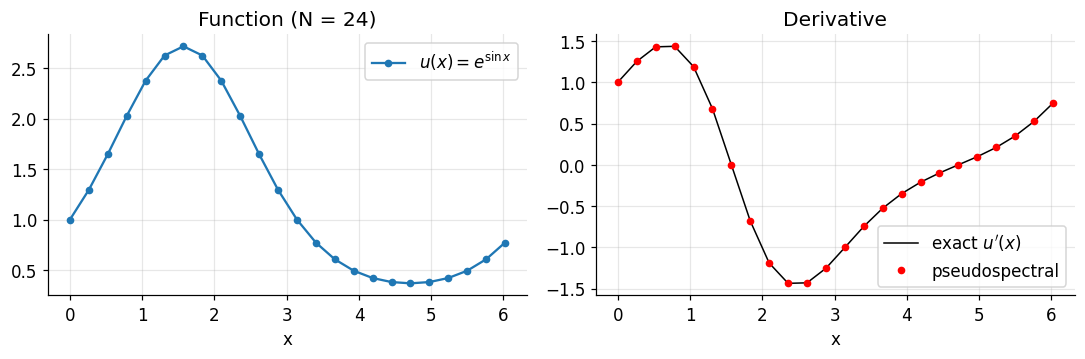

max |error| with N = 24: 9.55e-13


In [3]:
N = 24
L = 2 * np.pi
x = np.arange(N) * L / N

u = np.exp(np.sin(x))
du_exact = np.cos(x) * np.exp(np.sin(x))
du_num = fourier_diff(u, L=L)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(x, u, "o-", ms=4, label="$u(x)=e^{\\sin x}$")
ax[0].set_xlabel("x"); ax[0].set_title("Function (N = %d)" % N); ax[0].legend()

ax[1].plot(x, du_exact, "k-", lw=1, label="exact $u'(x)$")
ax[1].plot(x, du_num, "ro", ms=4, label="pseudospectral")
ax[1].set_xlabel("x"); ax[1].set_title("Derivative"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"max |error| with N = {N}: {np.max(np.abs(du_num - du_exact)):.2e}")

### Convergence: spectral vs. finite differences

Finite differences should give algebraic convergence — second-order central differences satisfy
$\|u'_h - u'\|_\infty = \mathcal{O}(h^2) = \mathcal{O}(N^{-2})$. The Fourier pseudospectral
derivative on this analytic, periodic test function should converge **geometrically**.

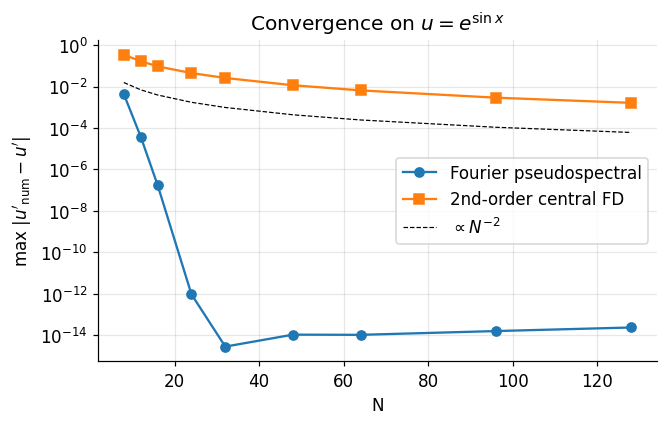

Pseudospectral hits machine precision near N ≈ 24 — note the log-y axis.


In [4]:
def fd2_periodic(u, L=2 * np.pi):
    '''Second-order central difference, periodic.'''
    N = len(u)
    h = L / N
    return (np.roll(u, -1) - np.roll(u, 1)) / (2 * h)


Ns = np.array([8, 12, 16, 24, 32, 48, 64, 96, 128])
err_ps, err_fd = [], []
for N in Ns:
    x = np.arange(N) * L / N
    u = np.exp(np.sin(x))
    du_exact = np.cos(x) * np.exp(np.sin(x))
    err_ps.append(np.max(np.abs(fourier_diff(u, L) - du_exact)))
    err_fd.append(np.max(np.abs(fd2_periodic(u, L) - du_exact)))

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.semilogy(Ns, err_ps, "o-", label="Fourier pseudospectral")
ax.semilogy(Ns, err_fd, "s-", label="2nd-order central FD")
ax.semilogy(Ns, 1.0 / Ns**2, "k--", lw=0.8, label=r"$\propto N^{-2}$")
ax.set_xlabel("N"); ax.set_ylabel(r"max $|u'_{\rm num}-u'|$")
ax.set_title("Convergence on $u=e^{\\sin x}$")
ax.legend(); plt.tight_layout(); plt.show()

print("Pseudospectral hits machine precision near N ≈ 24 — note the log-y axis.")

The pseudospectral error plummets to roundoff around $N\approx 24$, while finite differences
crawl down at the predicted $N^{-2}$ rate. This is the signature of spectral accuracy.

## 3. Chebyshev pseudospectral differentiation

For non-periodic problems on $[-1,1]$ we use **Chebyshev–Gauss–Lobatto** (CGL) points

$$
x_j = \cos\!\left(\frac{j\pi}{N}\right),\qquad j=0,1,\dots,N,
$$

which cluster quadratically near $\pm 1$. This clustering is essential — it suppresses the
**Runge phenomenon** that ruins polynomial interpolation on equispaced grids.

The unique polynomial of degree $\le N$ matching $u$ at $\{x_j\}$ has a derivative whose values at
the same points are given by a fixed matrix $D\in\mathbb{R}^{(N+1)\times(N+1)}$. Trefethen's compact
formula (SMM, Program 1):

In [5]:
def cheb(N):
    '''Chebyshev-Gauss-Lobatto points and differentiation matrix on [-1, 1].

    Trefethen, Spectral Methods in MATLAB, Program 1. Returns x with x[0]=1, x[N]=-1.
    '''
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))   # off-diagonal
    D = D - np.diag(D.sum(axis=1))                    # diagonal: row sums = 0
    return D, x


D, x = cheb(8)
print("Chebyshev-Gauss-Lobatto points on [-1, 1]:")
print(x)
print("\nDifferentiation matrix D (8x8 case shown for compactness):")
print(D)

Chebyshev-Gauss-Lobatto points on [-1, 1]:
[ 1.      0.9239  0.7071  0.3827  0.     -0.3827 -0.7071 -0.9239 -1.    ]

Differentiation matrix D (8x8 case shown for compactness):
[[ 21.5    -26.2741   6.8284  -3.2398   2.      -1.4465   1.1716  -1.0396
    0.5   ]
 [  6.5685  -3.1543  -4.6131   1.8478  -1.0824   0.7654  -0.6131   0.5412
   -0.2599]
 [ -1.7071   4.6131  -0.7071  -3.0824   1.4142  -0.9176   0.7071  -0.6131
    0.2929]
 [  0.81    -1.8478   3.0824  -0.2242  -2.6131   1.3066  -0.9176   0.7654
   -0.3616]
 [ -0.5      1.0824  -1.4142   2.6131   0.      -2.6131   1.4142  -1.0824
    0.5   ]
 [  0.3616  -0.7654   0.9176  -1.3066   2.6131   0.2242  -3.0824   1.8478
   -0.81  ]
 [ -0.2929   0.6131  -0.7071   0.9176  -1.4142   3.0824   0.7071  -4.6131
    1.7071]
 [  0.2599  -0.5412   0.6131  -0.7654   1.0824  -1.8478   4.6131   3.1543
   -6.5685]
 [ -0.5      1.0396  -1.1716   1.4465  -2.       3.2398  -6.8284  26.2741
  -21.5   ]]


### Why the diagonal correction `D = D - diag(D.sum(axis=1))`?

A constant function $u\equiv 1$ must satisfy $Du=0$. So every row of $D$ must sum to zero.
Trefethen's trick: compute the off-diagonals from the closed-form formula, then *define* the
diagonal entry as $D_{jj} := -\sum_{k\neq j} D_{jk}$. This avoids the catastrophic cancellation
that the closed-form expression $D_{jj}=-x_j/(2(1-x_j^2))$ suffers near the boundaries.

### Test: $u(x)=e^{x}\sin(5x)$, $\quad u'(x)=e^x(\sin 5x + 5\cos 5x)$

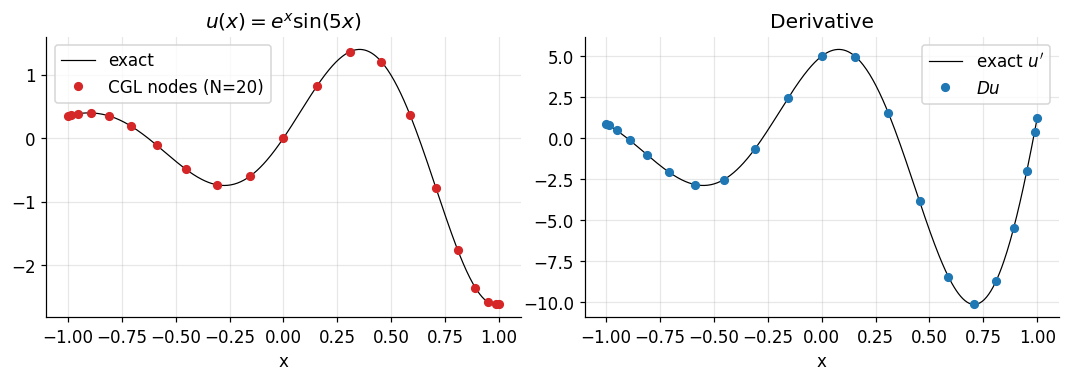

max |error| with N = 20: 6.72e-10


In [6]:
def test_func(x):
    return np.exp(x) * np.sin(5 * x)

def test_func_prime(x):
    return np.exp(x) * (np.sin(5 * x) + 5 * np.cos(5 * x))


N = 20
D, x = cheb(N)
u = test_func(x)
du_num = D @ u
du_exact = test_func_prime(x)

xx = np.linspace(-1, 1, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

ax[0].plot(xx, test_func(xx), "k-", lw=0.8, label="exact")
ax[0].plot(x, u, "o", color="C3", ms=5, label=f"CGL nodes (N={N})")
ax[0].set_title("$u(x)=e^x\\sin(5x)$"); ax[0].set_xlabel("x"); ax[0].legend()

ax[1].plot(xx, test_func_prime(xx), "k-", lw=0.8, label="exact $u'$")
ax[1].plot(x, du_num, "o", color="C0", ms=5, label="$Du$")
ax[1].set_title("Derivative"); ax[1].set_xlabel("x"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"max |error| with N = {N}: {np.max(np.abs(du_num - du_exact)):.2e}")

### Convergence study

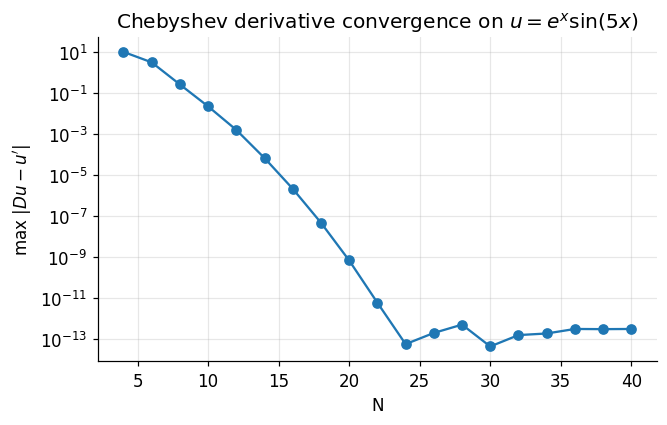

In [7]:
Ns = np.arange(4, 41, 2)
errs = []
for N in Ns:
    D, x = cheb(N)
    errs.append(np.max(np.abs(D @ test_func(x) - test_func_prime(x))))

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.semilogy(Ns, errs, "o-")
ax.set_xlabel("N"); ax.set_ylabel(r"max $|Du - u'|$")
ax.set_title("Chebyshev derivative convergence on $u=e^x\\sin(5x)$")
plt.tight_layout(); plt.show()

Straight line on a semilog-y plot $\Leftrightarrow$ geometric (exponential) convergence in $N$.
Once we hit machine precision (~$10^{-14}$) the error stalls and even drifts up slightly because
$D$ has condition number that grows like $N^2$ for first derivatives.

## 4. Clenshaw–Curtis quadrature

Idea: integrate the polynomial interpolant exactly. The CGL nodes paired with the Clenshaw–Curtis
weights produce a quadrature rule

$$
\int_{-1}^{1} f(x)\,dx \;\approx\; \sum_{j=0}^{N} w_j f(x_j)
$$

that is **exact** for polynomials of degree $\le N$ (sometimes $N+1$, depending on parity) and, more
importantly, converges geometrically for analytic integrands. The weights have a closed form
expressible via the DCT, so they cost $\mathcal{O}(N\log N)$.

In [8]:
def clencurt(N):
    '''Clenshaw-Curtis nodes and weights on [-1, 1].

    Trefethen, SMM, Program 30. N+1 nodes, weights sum to 2.
    '''
    theta = np.pi * np.arange(N + 1) / N
    x = np.cos(theta)
    w = np.zeros(N + 1)
    ii = np.arange(1, N)
    v = np.ones(N - 1)
    for k in range(1, N // 2 + 1):
        if 2 * k == N:
            v -= np.cos(2 * k * theta[ii]) / (4 * k**2 - 1)
        else:
            v -= 2 * np.cos(2 * k * theta[ii]) / (4 * k**2 - 1)
    # Endpoint weight: 1/(N^2-1) for even N, 1/N^2 for odd N.
    w[0] = 1.0 / (N**2 - 1 + (N % 2))
    w[N] = w[0]
    w[1:N] = 2 * v / N
    return x, w


x, w = clencurt(16)
print(f"sum of weights (should be 2): {w.sum():.15f}")

sum of weights (should be 2): 2.000000000000000


### Test integrals

* $I_1=\int_{-1}^{1} e^{-x^2}\cos(2x)\,dx$ (analytic) — expect geometric convergence.
* $I_2=\int_{-1}^{1} |x|^3\,dx = 1/2$ ($C^2$ but not $C^3$) — expect algebraic $\mathcal O(N^{-4})$.
* Compare to the trapezoidal rule on equispaced points.

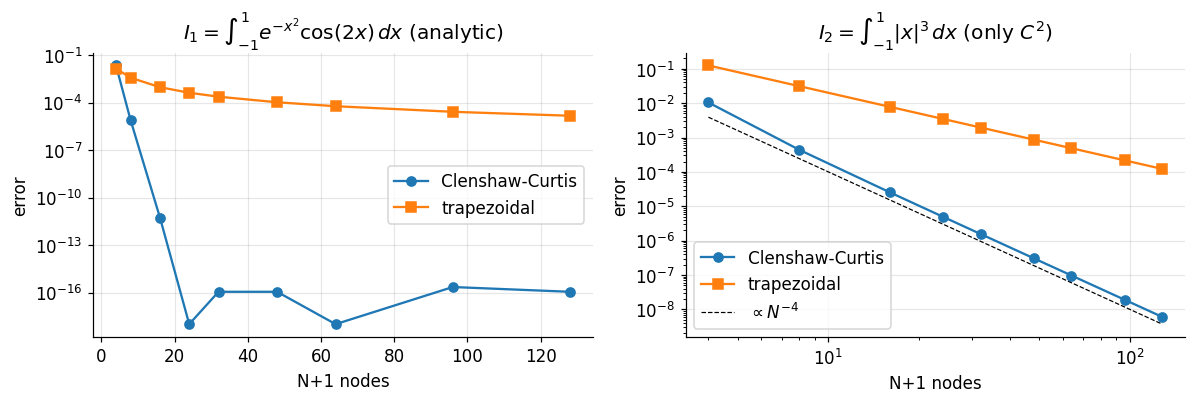

In [9]:
def trap_quad(f, N):
    '''Trapezoidal rule with N+1 equispaced points on [-1, 1].'''
    x = np.linspace(-1, 1, N + 1)
    h = 2.0 / N
    return h * (0.5 * f(x[0]) + f(x[1:-1]).sum() + 0.5 * f(x[-1]))


I1_ref, _ = si.quad(lambda x: np.exp(-x**2) * np.cos(2 * x), -1, 1, epsabs=1e-15)
I2_ref = 0.5

f1 = lambda x: np.exp(-x**2) * np.cos(2 * x)
f2 = lambda x: np.abs(x) ** 3

Ns = np.array([4, 8, 16, 24, 32, 48, 64, 96, 128])
err_cc1, err_tr1 = [], []
err_cc2, err_tr2 = [], []
for N in Ns:
    x, w = clencurt(N)
    err_cc1.append(abs((w * f1(x)).sum() - I1_ref))
    err_cc2.append(abs((w * f2(x)).sum() - I2_ref))
    err_tr1.append(abs(trap_quad(f1, N) - I1_ref))
    err_tr2.append(abs(trap_quad(f2, N) - I2_ref))

# Replace exact zeros with a tiny floor so semilogy still draws them.
def floor_zeros(arr, eps=1e-18):
    a = np.array(arr, dtype=float)
    a[a == 0] = eps
    return a

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].semilogy(Ns, floor_zeros(err_cc1), "o-", label="Clenshaw-Curtis")
ax[0].semilogy(Ns, floor_zeros(err_tr1), "s-", label="trapezoidal")
ax[0].set_title(r"$I_1=\int_{-1}^{1}e^{-x^2}\cos(2x)\,dx$ (analytic)")
ax[0].set_xlabel("N+1 nodes"); ax[0].set_ylabel("error"); ax[0].legend()

ax[1].loglog(Ns, floor_zeros(err_cc2), "o-", label="Clenshaw-Curtis")
ax[1].loglog(Ns, floor_zeros(err_tr2), "s-", label="trapezoidal")
ax[1].loglog(Ns, 1.0 / Ns ** 4, "k--", lw=0.8, label=r"$\propto N^{-4}$")
ax[1].set_title(r"$I_2=\int_{-1}^{1}|x|^3\,dx$ (only $C^2$)")
ax[1].set_xlabel("N+1 nodes"); ax[1].set_ylabel("error"); ax[1].legend()

plt.tight_layout(); plt.show()

**Reading the plots.**

* For the analytic integrand (left), Clenshaw–Curtis hits roundoff by $N\approx 24$ — geometric
  convergence. The trapezoidal rule plods along at $\mathcal{O}(N^{-2})$.
* For the $C^2$ integrand $|x|^3$ (right), both rules show *algebraic* convergence. Clenshaw–Curtis
  achieves $\mathcal{O}(N^{-4})$ (it benefits from the singularity sitting between nodes), while
  trapezoidal gets only $\mathcal{O}(N^{-2})$. Spectral accuracy requires smooth integrands;
  Clenshaw–Curtis still wins, just no longer geometrically.

## 5. Boundary value problem

Solve

$$
-u''(x) = e^{4x},\quad x\in(-1,1),\qquad u(\pm 1)=0.
$$

The closed-form solution is $u(x) = \tfrac{1}{16}\!\left(\cosh 4 + x\sinh 4 - e^{4x}\right)$, which we'll
use to measure the error.

### Method

1. Build $D$ with `cheb(N)`. Form $D^2 = D\cdot D$.
2. Apply Dirichlet BCs by **deleting the first and last rows and columns** of $D^2$.
3. Solve the linear system $-D^2_{\rm int}\,u_{\rm int} = f_{\rm int}$ for the interior values.
4. Glue the zero boundary values back on.

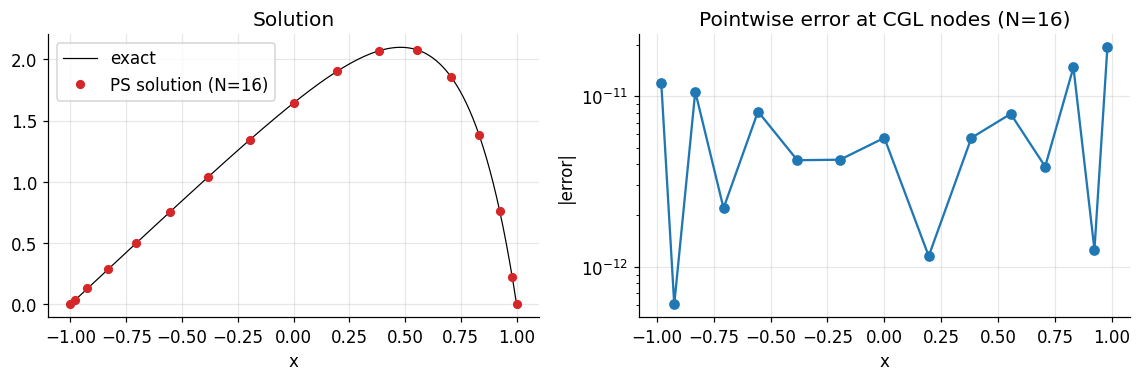

max nodal error at N = 16: 1.94e-11


In [10]:
def solve_bvp_chebyshev(N, f):
    '''Solve -u''=f on [-1,1] with u(±1)=0.'''
    D, x = cheb(N)
    D2 = D @ D
    # interior block (drop boundary rows/cols)
    A = -D2[1:-1, 1:-1]
    b = f(x[1:-1])
    u_int = np.linalg.solve(A, b)
    u = np.concatenate(([0.0], u_int, [0.0]))
    return x, u


# Exact solution for f(x)=exp(4x).
def u_exact(x):
    return (np.cosh(4) + x * np.sinh(4) - np.exp(4 * x)) / 16.0


N = 16
x, u = solve_bvp_chebyshev(N, lambda x: np.exp(4 * x))

xx = np.linspace(-1, 1, 400)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
ax[0].plot(xx, u_exact(xx), "k-", lw=0.8, label="exact")
ax[0].plot(x, u, "o", color="C3", ms=5, label=f"PS solution (N={N})")
ax[0].set_xlabel("x"); ax[0].set_title("Solution"); ax[0].legend()

ax[1].semilogy(x[1:-1], np.abs(u[1:-1] - u_exact(x[1:-1])), "o-")
ax[1].set_xlabel("x"); ax[1].set_ylabel("|error|")
ax[1].set_title(f"Pointwise error at CGL nodes (N={N})")
plt.tight_layout(); plt.show()

print(f"max nodal error at N = {N}: {np.max(np.abs(u - u_exact(x))):.2e}")

### Convergence

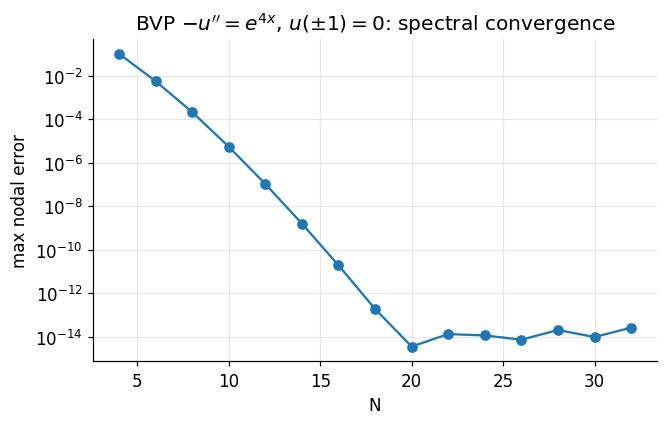

In [11]:
Ns = np.arange(4, 33, 2)
errs = []
for N in Ns:
    x, u = solve_bvp_chebyshev(N, lambda x: np.exp(4 * x))
    errs.append(np.max(np.abs(u - u_exact(x))))

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.semilogy(Ns, errs, "o-")
ax.set_xlabel("N"); ax.set_ylabel("max nodal error")
ax.set_title(r"BVP $-u''=e^{4x}$, $u(\pm1)=0$: spectral convergence")
plt.tight_layout(); plt.show()

Same exponential decay we saw for plain differentiation. Roughly $N=14$ already gives
machine-precision accuracy on a problem where second-order finite differences would need
thousands of points to match.

### Variable coefficients and Robin BCs

For $-(a(x)u')' + c(x)u = f$ with mixed BCs, the recipe generalizes:

* Form $A = -\operatorname{diag}(a)\,D^2 - \operatorname{diag}(a')\,D + \operatorname{diag}(c)$.
* For Robin/Neumann BCs you don't drop those rows; instead overwrite them with the BC equation
  $\alpha u(x_j) + \beta(Du)_j = g$.

## 6. Time-dependent PDE: the heat equation

Solve $u_t = \nu u_{xx}$ on a periodic interval. In Fourier space each mode evolves independently,

$$
\hat u_k(t) = \hat u_k(0)\, e^{-\nu k^2 t},
$$

so we can take **arbitrarily large time steps** and remain exact. (No CFL condition because we are
not stepping with finite differences in time — we are just multiplying.)

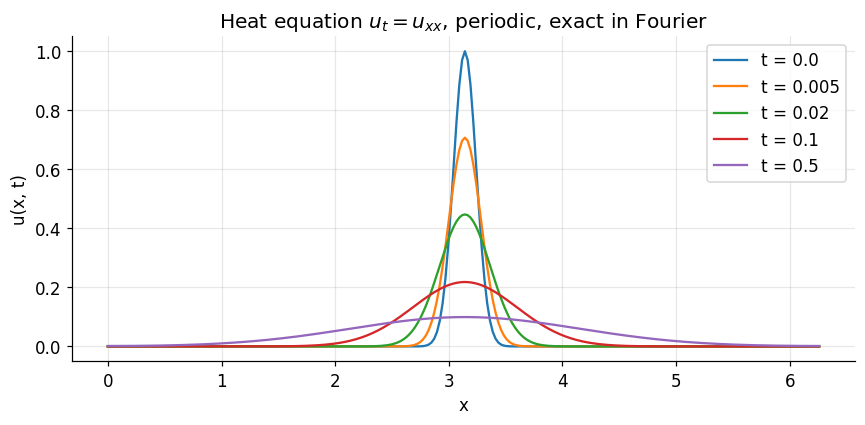

In [12]:
def heat_solve(u0, t, L=2 * np.pi, nu=1.0):
    '''Exact heat-equation evolution for periodic IC u0 over time t.'''
    N = len(u0)
    k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
    return np.real(np.fft.ifft(np.fft.fft(u0) * np.exp(-nu * k**2 * t)))


L = 2 * np.pi
N = 256
x = np.arange(N) * L / N

# A "delta-like" sharp Gaussian initial condition.
u0 = np.exp(-50.0 * (x - np.pi) ** 2)

times = [0.0, 0.005, 0.02, 0.1, 0.5]
fig, ax = plt.subplots(figsize=(8, 4))
for t in times:
    ax.plot(x, heat_solve(u0, t, L=L, nu=1.0), label=f"t = {t}")
ax.set_xlabel("x"); ax.set_ylabel("u(x, t)")
ax.set_title(r"Heat equation $u_t = u_{xx}$, periodic, exact in Fourier")
ax.legend(); plt.tight_layout(); plt.show()

The peak diffuses out and the total mass $\int u\,dx$ is preserved exactly (mode $k=0$ is
multiplied by $1$). Energy in higher modes decays at rate $e^{-k^2 t}$ — the rapid disappearance of
short wavelengths is visible as the curves smoothing out.

### What about nonlinear or non-constant-coefficient problems?

The trick of "diagonalize-and-evolve" only works for constant-coefficient linear PDEs.
For nonlinear PDEs (e.g. $u_t + uu_x = \nu u_{xx}$, the viscous Burgers equation) the standard
pattern is:

* Compute spatial derivatives pseudospectrally (FFT for periodic, $D$-matrix for Chebyshev).
* Use an explicit ODE integrator in time (RK4, Dormand–Prince, etc.), often with **integrating
  factors** to remove the stiffness from the highest-order linear term.

The next cell shows a quick **viscous Burgers** integration as a concrete nonlinear example.

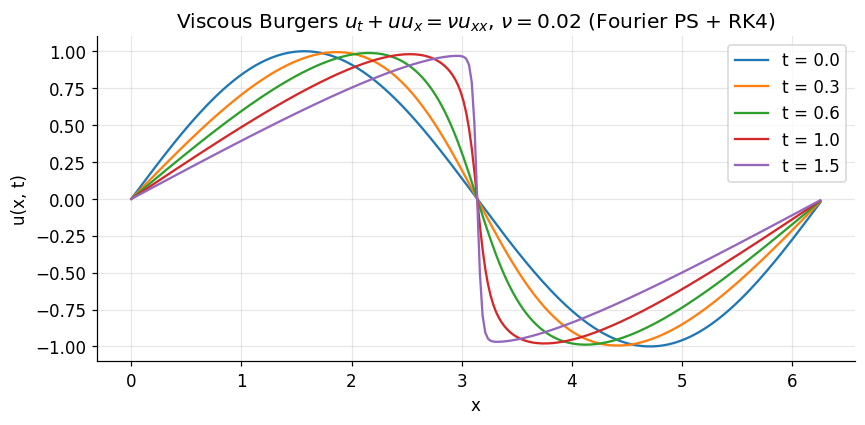

In [13]:
def burgers_rhs(u, k, nu, dealias_mask):
    '''RHS of u_t = -u u_x + nu u_xx in Fourier space, with 2/3 dealiasing.'''
    u_hat = np.fft.fft(u)
    u_hat_d = u_hat * dealias_mask
    u_d = np.real(np.fft.ifft(u_hat_d))
    ux = np.real(np.fft.ifft(1j * k * u_hat))
    uxx = np.real(np.fft.ifft(-k**2 * u_hat))
    return -u_d * ux + nu * uxx


def rk4_step(f, u, dt, *args):
    k1 = f(u, *args)
    k2 = f(u + 0.5 * dt * k1, *args)
    k3 = f(u + 0.5 * dt * k2, *args)
    k4 = f(u + dt * k3, *args)
    return u + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


L = 2 * np.pi
N = 256
x = np.arange(N) * L / N
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)

# 2/3 rule dealiasing mask: zero modes with |k| > N/3.
dealias_mask = (np.abs(k) <= (2.0 / 3.0) * (N / 2) * (2 * np.pi / L)).astype(float)

nu = 0.02
u = np.sin(x)             # smooth IC; will steepen into a near-shock
T = 1.5
dt = 5e-4
nsteps = int(T / dt)
snaps = {0.0: u.copy()}
save_times = [0.3, 0.6, 1.0, 1.5]
next_save = 0
t = 0.0
for n in range(nsteps):
    u = rk4_step(burgers_rhs, u, dt, k, nu, dealias_mask)
    t += dt
    if next_save < len(save_times) and t >= save_times[next_save] - 1e-9:
        snaps[save_times[next_save]] = u.copy()
        next_save += 1

fig, ax = plt.subplots(figsize=(8, 4))
for t_save, u_save in snaps.items():
    ax.plot(x, u_save, label=f"t = {t_save}")
ax.set_xlabel("x"); ax.set_ylabel("u(x, t)")
ax.set_title(r"Viscous Burgers $u_t + u u_x = \nu u_{xx}$, $\nu=0.02$ (Fourier PS + RK4)")
ax.legend(); plt.tight_layout(); plt.show()

The smooth sine wave steepens into a viscous shock. Two implementation notes worth
internalizing:

* **Dealiasing.** The product $u\cdot u_x$ in physical space corresponds to a convolution in Fourier
  space. Computing it pseudospectrally introduces aliasing errors; the 2/3 rule (zero out the top
  third of modes after each multiplication) recovers spectral accuracy for quadratic nonlinearities.
* **Time-step restriction.** Without integrating factors the diffusion term $\nu u_{xx}$ imposes
  $\Delta t \lesssim 1/(\nu\,k_{\max}^2)$. For stiffer problems (e.g. KdV's $u_{xxx}$) you'd want
  ETD-RK4 or IFRK4.

## 7. Eigenvalue problem: quantum harmonic oscillator

Solve

$$
-u''(x) + x^2\, u(x) = E\, u(x),\qquad u(\pm\infty)=0.
$$

Exact eigenvalues: $E_n = 2n+1$ for $n=0,1,2,\dots$.

We approximate $\mathbb{R}$ by a large interval $[-L, L]$ with $u(\pm L)=0$. As long as $L$ is wide
enough that the lowest eigenfunctions decay to roundoff at the boundary, the truncation error is
negligible — and Chebyshev pseudospectral converges geometrically in $N$.

In [14]:
def harmonic_oscillator(N, L=8.0):
    '''Discretize -u'' + x^2 u on [-L, L] with Dirichlet BCs via Chebyshev PS.'''
    D, xi = cheb(N)              # xi in [-1, 1]
    x = L * xi                   # rescale to [-L, L]
    Dx = D / L                   # chain rule
    D2x = Dx @ Dx
    H = -D2x + np.diag(x**2)
    # Apply u(±L)=0 by removing first and last rows/cols.
    Hi = H[1:-1, 1:-1]
    eigvals, eigvecs = la.eig(Hi)
    idx = np.argsort(eigvals.real)
    return x, eigvals.real[idx], eigvecs[:, idx]


N, L = 60, 8.0
x, E, V = harmonic_oscillator(N, L=L)

print("First 8 eigenvalues vs exact 2n+1:")
print(f"  {'n':>2}  {'computed':>16}  {'exact':>6}  {'|error|':>10}")
for n in range(8):
    print(f"  {n:>2}  {E[n]:>16.12f}  {2*n+1:>6d}  {abs(E[n] - (2*n+1)):>10.2e}")

First 8 eigenvalues vs exact 2n+1:
   n          computed   exact     |error|
   0    1.000000000000       1    1.55e-15
   1    3.000000000000       3    1.64e-14
   2    5.000000000000       5    1.51e-14
   3    7.000000000000       7    3.55e-15
   4    9.000000000000       9    4.80e-14
   5   11.000000000001      11    5.74e-13
   6   12.999999999994      13    6.43e-12
   7   15.000000000059      15    5.86e-11


/tmp/ipykernel_632/3269433827.py:6: RuntimeWarning: invalid value encountered in sqrt
  psi = psi / np.sqrt(np.trapezoid(psi**2, xi))   # L2-normalize


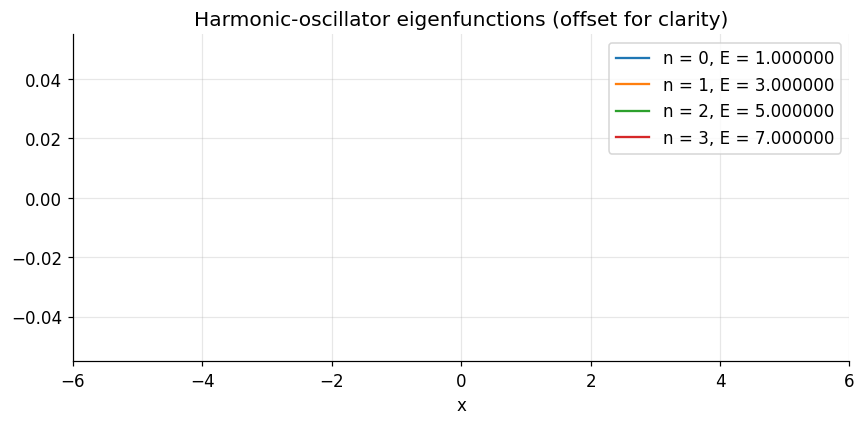

In [15]:
# Plot the first four eigenfunctions on the interior grid.
xi = x[1:-1]
fig, ax = plt.subplots(figsize=(8, 4))
for n in range(4):
    psi = V[:, n].real
    psi = psi / np.sqrt(np.trapezoid(psi**2, xi))   # L2-normalize
    if psi[len(psi) // 2] < 0:                  # fix sign for visual consistency
        psi = -psi
    ax.plot(xi, psi + 2 * n, label=f"n = {n}, E = {E[n]:.6f}")
ax.set_xlim(-6, 6)
ax.set_xlabel("x"); ax.set_title("Harmonic-oscillator eigenfunctions (offset for clarity)")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

### Convergence in $N$

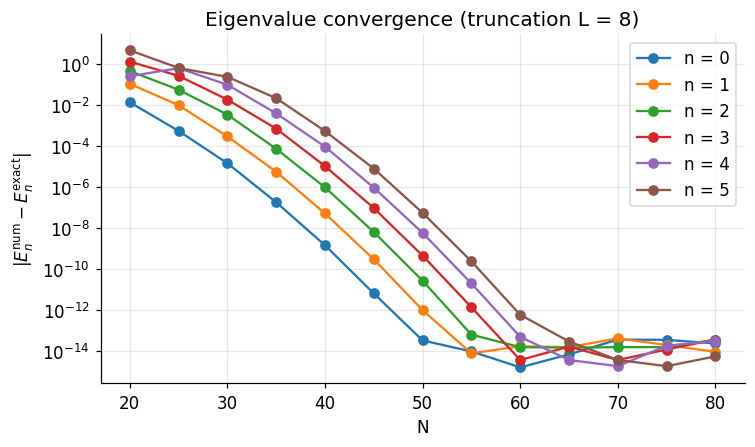

In [16]:
Ns = np.arange(20, 81, 5)
errs = {n: [] for n in range(6)}
for N in Ns:
    _, E, _ = harmonic_oscillator(N, L=8.0)
    for n in range(6):
        errs[n].append(abs(E[n] - (2 * n + 1)))

fig, ax = plt.subplots(figsize=(7, 4.2))
for n in range(6):
    ax.semilogy(Ns, np.maximum(errs[n], 1e-16), "o-", label=f"n = {n}")
ax.set_xlabel("N"); ax.set_ylabel(r"$|E_n^{\rm num} - E_n^{\rm exact}|$")
ax.set_title("Eigenvalue convergence (truncation L = 8)")
ax.legend(); plt.tight_layout(); plt.show()

Each eigenvalue converges geometrically until it hits roundoff. Higher modes stall later
because they extend further out — they're more sensitive to the truncation $L$ and need slightly
larger $N$.

## 8. Summary and practical recipe

The pseudospectral playbook in one paragraph: pick collocation nodes that match your geometry —
**equispaced for periodic** problems (use FFT), **Chebyshev–Gauss–Lobatto for non-periodic** (use
$D$-matrix). Differentiate by FFT or by matrix-vector multiply. Quadrature: Clenshaw–Curtis on the
same CGL grid. For BVPs, build the operator from $D$ and impose BCs by row replacement. For
time-dependent problems, treat space pseudospectrally and time with your favorite ODE integrator,
adding integrating factors if a high-order linear term is stiff. For eigenvalues, build the
operator and call `eig`.

### When pseudospectral is the wrong tool

* **Discontinuities / shocks.** The Gibbs phenomenon kills accuracy globally. Use DG, ENO, or finite
  volumes with limiters.
* **Complicated geometry.** Pseudospectral lives on tensor-product domains. For arbitrary geometry
  use spectral elements (e.g. Nektar++, Nek5000) or hp-FEM.
* **Very low smoothness.** If $u\in C^k$ for small $k$, the convergence is only algebraic — finite
  elements with adaptive refinement may be more efficient and easier to implement.

### Things worth implementing yourself once

* Mapping to non-standard intervals: $x = \tfrac{1}{2}(b-a)\xi + \tfrac{1}{2}(b+a)$ scales $D$ by
  $2/(b-a)$.
* Mapping to semi-infinite or infinite domains: rational-Chebyshev or Hermite functions.
* Tensor-product 2D/3D differentiation: $D_x \otimes I + I \otimes D_y$.
* ETDRK4 for stiff PDEs (Cox–Matthews).

### Further reading

* L. N. Trefethen, *Spectral Methods in MATLAB* (SIAM, 2000) — the canonical short introduction.
* J. P. Boyd, *Chebyshev and Fourier Spectral Methods* (Dover, 2001) — encyclopedic, free PDF online.
* B. Fornberg, *A Practical Guide to Pseudospectral Methods* (CUP, 1996).
* J. S. Hesthaven, S. Gottlieb, D. Gottlieb, *Spectral Methods for Time-Dependent Problems* (CUP, 2007).
* Driscoll, Hale & Trefethen, **Chebfun** (https://www.chebfun.org/) — production-quality Chebyshev/Fourier toolkit in MATLAB.